In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())
from scipy.stats import pearsonr, spearmanr
from matplotlib.colors import LogNorm

2180087


In [3]:
AA_TO_IDX = {
    'A':0,  'C':1,  'D':2,  'E':3,  'F':4,
    'G':5,  'H':6,  'I':7,  'K':8,  'L':9,
    'M':10, 'N':11, 'P':12, 'Q':13, 'R':14,
    'S':15, 'T':16, 'V':17, 'W':18, 'Y':19,
    '-':20,   # gap / insertion
    'X':21    # unknown residue
}

In [4]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [5]:
# Build graph data for a single sequence
def build_graph(filename, sequence, score_map, distance_map=None, sep_min=0):
    
    N = len(sequence)

    # score map to tensor
    score_map = torch.tensor(score_map, dtype=torch.float)
    #score_map = torch.log(score_map + 1.0)  #renormalization to see again when we have more data
    #score_map = (score_map - score_map.mean()) / (score_map.std() + 1e-6)
    idx = torch.arange(N)
    i, j = torch.meshgrid(idx, idx, indexing='ij')  # shape [N, N]

    sep = torch.abs(i - j).float()
    sep_bucket = torch.clamp(sep, max=32).long()


    # masks
    not_self = i != j
    pair_mask = i < j
    long_range_ok = (torch.abs(i - j) >= sep_min)

    if distance_map is not None:
        distance_map = torch.tensor(distance_map, dtype=torch.float)
        distance_map=torch.log((distance_map)/8) #renormalization to see again when we have more data
        known = torch.isfinite(distance_map)
        labels = distance_map
    else:
        known = torch.ones((N, N), dtype=torch.bool)
        labels = torch.zeros((N, N), dtype=torch.float)

    edge_mask = known & long_range_ok

    # remove i == j
    valid = not_self

    src = i[valid]
    dst = j[valid]

    # after you create src, dst for all i != j
    edge_to_idx = {(int(s), int(d)): k for k, (s, d) in enumerate(zip(src.tolist(), dst.tolist()))}
    rev_edge_idx = torch.tensor([edge_to_idx[(int(d), int(s))] for s, d in zip(src.tolist(), dst.tolist())],dtype=torch.long)

    edge_index = torch.stack([src, dst], dim=0)

    #edge_attr = score_map[valid].unsqueeze(-1)
    y = labels[valid].unsqueeze(-1)

    mask = edge_mask[valid]
    pair_mask = pair_mask[valid]

    x = sinusoidal_positional_encoding(N, d_model=16) #positional encoding
    

    seq_idx = torch.tensor([AA_TO_IDX.get(aa, 21) for aa in sequence],dtype=torch.long)


    return Data(
        x=x,
        seq_idx=seq_idx,
        edge_index=edge_index,
        edge_attr = torch.stack([score_map[valid],sep_bucket[valid].float()], dim=-1),
        y=y,
        edge_mask=mask,
        pair_mask=pair_mask,
        rev_edge_idx=rev_edge_idx,
        filename=filename,
        L=N
    )

In [6]:
folder_path = "Data_C_alpha"

all_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        filename=str(file)
        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']
        data = build_graph(filename,sequence, contact_map_DCA, distance_map)
        all_data.append(data)


from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# train_loader=DataLoader(all_data, batch_size=1, shuffle=True) 
# test_loader=DataLoader(all_data, batch_size=1, shuffle=True) 

train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=0)


train_loader = DataLoader(train_data, batch_size=1, shuffle=True) 
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [7]:
for batch in train_loader:
    print(batch.seq_idx)

tensor([ 0,  2,  8, 12,  2,  9,  5,  3,  7, 11, 15,  4,  2,  8,  0,  8,  9,  8,
         8, 16,  3, 16, 13,  3,  8, 11, 16,  9, 12, 16,  8,  3, 16,  7,  3, 13,
         3,  8, 13])
tensor([20,  0,  9,  9,  3,  0,  4,  5, 16, 16,  5,  4, 13,  0, 16, 11,  4,  5,
        14,  0, 17, 13, 13, 17, 11,  0,  9,  3, 12,  9, 16, 15,  1, 16,  7,  4,
         9,  5, 19, 16, 15, 11,  9,  7, 15, 15,  5,  7, 14,  3, 16,  7, 14, 19,
         9, 17, 13,  6, 11, 10, 17,  2, 17,  9, 17, 16, 16,  0,  5,  5, 17,  3,
         3,  2,  9,  7,  8,  1,  9,  0, 20, 12, 16, 19,  9,  5,  3,  4, 15,  9,
        14,  5,  8,  3,  9, 14,  3, 11,  5,  7, 11, 14,  7,  5, 11,  9,  9, 17,
        12, 11,  3, 11, 19,  1,  8,  4,  3,  2, 18,  9, 10, 12,  7,  9,  2, 13,
        10, 17, 10,  3, 13, 17,  8, 18, 16, 12, 15,  8, 10,  7,  0, 14,  9,  5,
         8,  3,  7, 11, 11, 12,  3, 15, 17, 19, 19, 18,  0, 13,  8, 11,  6,  7,
        12, 17,  4, 15, 12,  0,  9, 16,  2,  5, 15,  9,  5, 20,  2, 10,  7,  4,
         4,  6, 15,

In [8]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out

In [9]:
from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, sep_emb_dim = 8, hidden_ch=128, mlp_hidden_ch=64,GNN_layers=4,node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None


        self.aa_embedding = nn.Embedding(22, 32)
        self.sep_embedding = nn.Embedding(33, sep_emb_dim) #bucket to have relative distance between point in the chain
        self.edge_embed = nn.Sequential(
            nn.Linear(1+sep_emb_dim+2*32, hidden_ch),
            nn.ReLU(),
            nn.Linear(hidden_ch, hidden_ch),
        )
        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
            
            
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = hidden_ch,
            node_out_ch = hidden_ch,
            edge_out_ch = hidden_ch
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(hidden_ch, hidden_ch),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 1):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(hidden_ch))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(hidden_ch))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=hidden_ch,
                edge_in_ch=hidden_ch,
                node_out_ch=hidden_ch,
                edge_out_ch=hidden_ch
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(hidden_ch, hidden_ch),
                nn.Sigmoid()
                ))


         # MLP head for edge classification
        self.edge_reg_head = nn.Sequential(
            nn.Linear(hidden_ch, mlp_hidden_ch),
            nn.LeakyReLU(),
            nn.Linear(mlp_hidden_ch, 1)   # length regression
        )

        self.edge_cls_head = nn.Sequential(
            nn.Linear(hidden_ch, mlp_hidden_ch),
            nn.LeakyReLU(),
            nn.Linear(mlp_hidden_ch, 1)   # contact logit
        )

    def forward(self, graph):
        x = graph.x
        seq_idx = graph.seq_idx
        edge_index = graph.edge_index
        edge_attr = graph.edge_attr
        batch = graph.batch

        seq_emb = self.aa_embedding(seq_idx) #embedding of the sequence

        x = torch.cat([x, seq_emb], dim=-1)

        src, dst = edge_index

        edge_batch = batch[src]  # batch degli edge = batch del nodo sorgente
        
        # --- split edge features ---
        score = edge_attr[:, 0:1]                     # [E, 1]
        sep_bucket = edge_attr[:, 1].long()           # [E]

        # --- embed separation ---
        sep_emb = self.sep_embedding(sep_bucket)      # [E, sep_emb_dim]

        edge_attr = torch.cat(
            [score, sep_emb, seq_emb[src], seq_emb[dst]],
            dim=-1
        )

        edge_attr = self.edge_embed(edge_attr)

        for i, conv in enumerate(self.convs):

            x_in = x
            e_in = edge_attr

            node_norm = self.node_norms[i]

            edge_norm = (
                self.edge_norms[i]
                if i < len(self.edge_norms)
                else None
            )

            x = node_norm(x, batch)

            if edge_norm is not None:
                edge_attr = edge_norm(edge_attr, edge_batch)

            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in

            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr)
                edge_attr = edge_attr * gate
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, 0.2)
            x = F.dropout(x, p=0.2, training=self.training)

            edge_attr = F.leaky_relu(edge_attr, 0.2)
            edge_attr = F.dropout(edge_attr, p=0.2, training=self.training)
        # Final projection to output space
        edge_reg = self.edge_reg_head(edge_attr)   # regression output
        edge_cls = self.edge_cls_head(edge_attr)   # classification logits

        return x, edge_reg, edge_cls

In [10]:
def triangle_inequality_loss_sampled(pred_dist_matrix, mask_matrix, num_samples=10000):
    B, N, _ = pred_dist_matrix.shape
    device = pred_dist_matrix.device
    # Randomly pick i, j, k indices
    i = torch.randint(0, N, (num_samples,), device=pred_dist_matrix.device)
    j = torch.randint(0, N, (num_samples,), device=pred_dist_matrix.device)
    k = torch.randint(0, N, (num_samples,), device=pred_dist_matrix.device)
    
    # remove degenerate triangles
    distinct = (i != j) & (i != k) & (j != k)
    i = i[distinct]
    j = j[distinct]
    k = k[distinct]

    d_ij = torch.exp(pred_dist_matrix[:, i, j])
    d_ik = torch.exp(pred_dist_matrix[:, i, k])
    d_jk = torch.exp(pred_dist_matrix[:, k, j])

    valid = (
        mask_matrix[:, i, j] &
        mask_matrix[:, i, k] &
        mask_matrix[:, k, j])
    
    v1 = torch.relu(d_ij - (d_ik + d_jk))
    v2 = torch.relu(d_ik - (d_ij + d_jk))
    v3 = torch.relu(d_jk - (d_ij + d_ik))

    violations = v1 + v2 + v3
    violations = violations[valid]
    
    if violations.numel() == 0:
        return torch.tensor(0.0, device=device)

    return torch.mean(violations**2)

In [11]:
from torch_geometric.utils import to_dense_adj
def compute_loss(batch, pred_dist, true_dist, epoch=0):
    valid = batch.edge_mask #& batch.pair_mask

    # separation bucket is already in edge_attr[:, 1]
    sep = batch.edge_attr[:, 1].long()

    #ignore very local pairs, upweight long-range ones
    weights = torch.ones_like(true_dist)

    weights[sep < 6] = 2.0
    weights[(sep >= 6) & (sep < 12)] = 3.0
    weights[sep >= 12] = 5.0        # long-range

    per_edge = F.smooth_l1_loss(
        pred_dist[valid],
        true_dist[valid],
        beta=0.1,
        reduction='none'
    )

    #main_loss
    main_loss = (weights[valid] * per_edge).sum() / (weights[valid].sum()+1e-8)

    #symmetry loss
    sym_loss = F.mse_loss(
        pred_dist[valid],
        pred_dist[batch.rev_edge_idx][valid]
    )

    #triangular loss
    dense_pred = to_dense_adj(batch.edge_index, batch.batch, edge_attr=pred_dist)
    dense_mask = to_dense_adj(batch.edge_index, batch.batch, edge_attr=batch.edge_mask.float()).bool()
    tri_loss = triangle_inequality_loss_sampled(dense_pred, dense_mask)

    λ_sym = min(0.1, epoch / 50 * 0.1)

    if epoch < 50:
        λ_tri = 0.0
    else:
        λ_tri = min(0.01, (epoch - 50) / 100 * 0.01)

    loss = main_loss + λ_sym * sym_loss + λ_tri * tri_loss
    
    return loss

In [12]:
def compute_pos_weight(loader, device):
    total_pos = 0
    total_neg = 0

    for batch in loader:
        batch = batch.to(device)

        y = batch.y.squeeze(-1)
        mask = batch.edge_mask #& batch.pair_mask  

        y = y[mask]

        total_pos += (y < 0).sum().item()
        total_neg += (y >= 0).sum().item()

    pos_weight = total_neg / max(total_pos, 1)
    return torch.tensor(pos_weight, dtype=torch.float, device=device)

In [13]:
def model_size(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )

    print(f"Total parameters:      {total_params:,}")
    print(f"Trainable parameters:  {trainable_params:,}")
    print(f"Non-trainable params:  {total_params - trainable_params:,}")

In [14]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
model = EdgeGNN(node_in_ch=48, sep_emb_dim=8, hidden_ch=128, mlp_hidden_ch=64, GNN_layers=4).to(device)
model_size(model)
save_path = "best_model_regressor+contact_C_alpha_drop_clip_seq.pt"
#to load an old model
# state_dict = torch.load(save_path)
# model.load_state_dict(state_dict)


optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5, patience=20,min_lr=1e-6)

pos_weight = compute_pos_weight(train_loader, device)
pos_weight = torch.tensor(8.0, device=device)  ###cambiato il pos weight, per vedere se è meglio clipparlo o no
print("pos_weight:", pos_weight.item())
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight,reduction='mean')

tr=np.log(11/8)



Total parameters:      651,946
Trainable parameters:  651,946
Non-trainable params:  0
pos_weight: 8.0


In [15]:
train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 100
epochs_no_improve = 0


for epoch in range(10000): 

    model.train()
    total_loss = 0.0
    total_edges = 0

    for batch in train_loader:
        batch = batch.to(device) 

        optimizer.zero_grad() 
        _, pred_dist, pred_logits = model(batch)

        mask = batch.edge_mask
        true_dist = batch.y.squeeze(-1)
        true_contacts = (true_dist < tr).float()   #contact at tr!
        pred_dist = pred_dist.squeeze(-1)
        pred_logits = pred_logits.squeeze(-1)

        loss_contact= loss_fn(pred_logits[mask], true_contacts[mask])

        loss_regression=compute_loss(batch,pred_dist,true_dist,epoch)

        loss = 3* loss_regression + loss_contact  #messo 3 per clipping

        #print(f"contact loss: {loss_contact.item()}, regression loss: {loss_regression.item()}")

        n_edges = mask.sum().item()
        total_loss += loss.item() * n_edges
        total_edges += n_edges

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  #gradient clipping
        optimizer.step()
    
    train_loss = total_loss / max(total_edges, 1)
    
    model.eval()
    total_loss_val = 0.0
    total_edges_val = 0

    with torch.no_grad():

        loss_contact_tot=[]
        loss_regression_tot=[]
        for batch in test_loader:
            batch = batch.to(device)

            _, pred_dist,pred_logits = model(batch)

            mask = batch.edge_mask
            true_dist = batch.y.squeeze(-1)
            true_contacts = (true_dist < tr).float()
            pred_dist = pred_dist.squeeze(-1)
            pred_logits = pred_logits.squeeze(-1)

            loss_contact= loss_fn(pred_logits[mask], true_contacts[mask])

            loss_regression=compute_loss(batch,pred_dist,true_dist,epoch)

            loss_contact_tot.append(loss_contact.item())
            loss_regression_tot.append(loss_regression.item())

            loss = 3* loss_regression + loss_contact  #messo 3 per clipping
            
            n_edges = mask.sum().item()
            total_loss_val += loss.item() * n_edges
            total_edges_val += n_edges
    

    val_loss= total_loss_val / max(total_edges_val, 1)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"contact loss: {np.mean(loss_contact_tot):.4f}, regression loss: {np.mean(loss_regression_tot):.4f}")
    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), save_path)

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break



contact loss: 1.0275, regression loss: 0.2680
Epoch 0: Train Loss=1.8075, Val Loss=1.6274
contact loss: 1.0537, regression loss: 0.2776
Epoch 1: Train Loss=1.6128, Val Loss=1.7785
contact loss: 0.9793, regression loss: 0.2666
Epoch 2: Train Loss=1.5628, Val Loss=1.5977
contact loss: 0.9701, regression loss: 0.2499
Epoch 3: Train Loss=1.5321, Val Loss=1.5399
contact loss: 0.9590, regression loss: 0.2439
Epoch 4: Train Loss=1.5191, Val Loss=1.5113
contact loss: 0.9532, regression loss: 0.2430
Epoch 5: Train Loss=1.5160, Val Loss=1.5080
contact loss: 0.9432, regression loss: 0.2379
Epoch 6: Train Loss=1.4998, Val Loss=1.4769
contact loss: 0.9443, regression loss: 0.2376
Epoch 7: Train Loss=1.4807, Val Loss=1.4661
contact loss: 0.9394, regression loss: 0.2363
Epoch 8: Train Loss=1.4680, Val Loss=1.4672
contact loss: 0.9297, regression loss: 0.2335
Epoch 9: Train Loss=1.4601, Val Loss=1.4451
contact loss: 0.9363, regression loss: 0.2369
Epoch 10: Train Loss=1.4534, Val Loss=1.4626
contact l

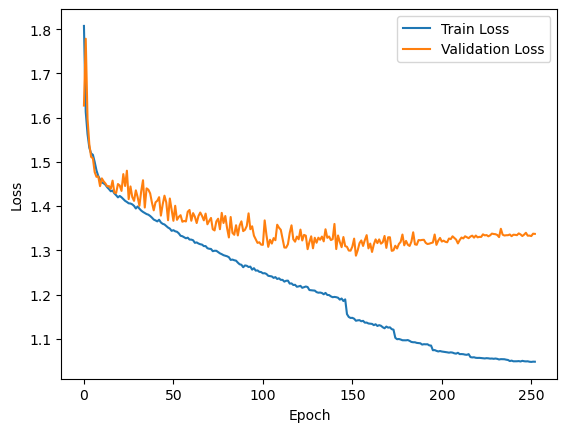

In [38]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [17]:
tr=np.log(11/8)

device= torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
model = EdgeGNN(node_in_ch=48, sep_emb_dim=8, hidden_ch=128, mlp_hidden_ch=64, GNN_layers=4).to(device)
save_path = "best_model_regressor+contact_C_alpha_drop_clip_seq.pt"


state_dict = torch.load(save_path)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [18]:
def graph_to_matrix(data, values, mask=None):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index

    if mask is not None:
        edge_index = edge_index[:, mask]
        values = values[mask]
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

Let's evaluate the contact prediction

Validation ROC AUC GNN: 0.9147143632439189


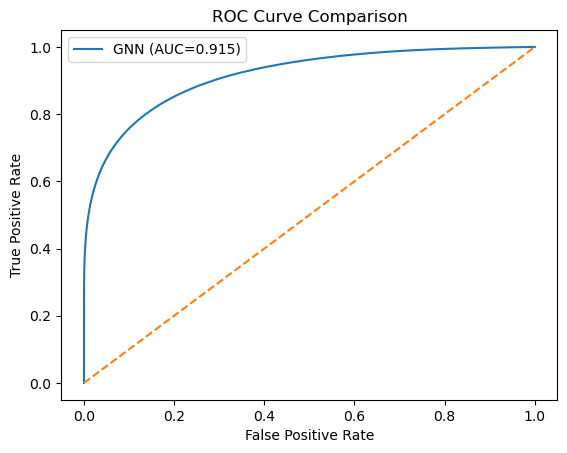

PR AUC GNN: 0.7280025687120285


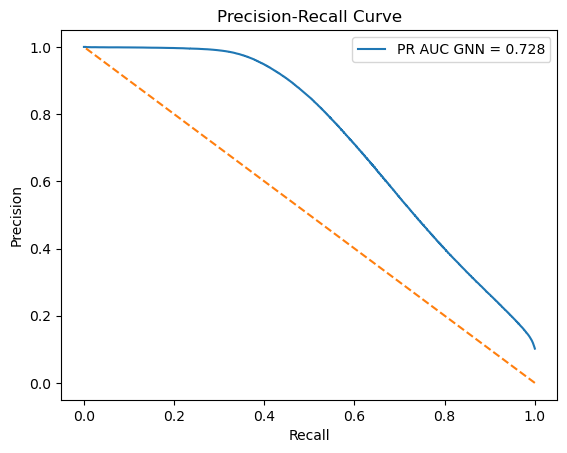

In [19]:
#roc and precision recall curve

from sklearn.metrics import auc, precision_score, recall_score, f1_score, average_precision_score, roc_curve

model.eval()

all_probs = []
all_true = []

for batch in test_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, _, pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_dist = batch.y.squeeze(-1)
    true_contacts = (true_dist < tr).float()
    mask = batch.edge_mask & batch.pair_mask
  


    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

print("Validation ROC AUC GNN:", roc_auc)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)


plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot([1, 0], [0, 1], linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [20]:
def topk_L_precision(model, loader, device, ratio=1.0):
    model.eval()
    per_graph_precisions = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _, _,logits = model(batch)

            probs = torch.sigmoid(logits.squeeze(-1))
            true_dist = batch.y.squeeze(-1)
            true_contacts = (true_dist < tr).float()

            valid_mask = batch.edge_mask & batch.pair_mask

            # graph id for each edge
            edge_graph_id = batch.batch[batch.edge_index[0]]

            num_graphs = batch.num_graphs

            for g in range(num_graphs):
                graph_mask = valid_mask & (edge_graph_id == g)

                probs_g = probs[graph_mask]
                true_g = true_contacts[graph_mask]

                if probs_g.numel() == 0:
                    continue

                # length of the protein
                L = int(batch.L[g]) if torch.is_tensor(batch.L) else int(batch.L)

                k = max(1, int(L * ratio))
                k = min(k, probs_g.numel())

                top_idx = torch.topk(probs_g, k=k).indices
                #knumber of true contacts in top-k​/k
                precision_g = (true_g[top_idx] > 0.5).float().mean().item()

                per_graph_precisions.append(precision_g)

    return float(np.mean(per_graph_precisions)), per_graph_precisions

print("Top-k*L precision:", topk_L_precision(model, test_loader, device, ratio=5)[0])

Top-k*L precision: 0.8806806242045684


In [21]:
#loader = DataLoader([train_loader.dataset[10]], batch_size=1)
# loader = DataLoader([test_data[2]], batch_size=1)
# batch = next(iter(loader)).to(device)
k=2

prec=[]
prec_dca=[]
for batch in test_loader:
    batch = batch.to(device)

    #accuracy for a single batch
    with torch.no_grad():
        _, _,pred_logits = model(batch)
        scores = torch.sigmoid(pred_logits.squeeze(-1))
        scores_dca = batch.edge_attr[:, 0].squeeze(-1)  # DCA scores

    mask = batch.edge_mask & batch.pair_mask
    scores = scores[mask]
    scores_dca = scores_dca[mask]
    true_dist = batch.y.squeeze(-1)[mask]
    true_contacts = (true_dist < tr).float()
    
    L = batch.L
    topk = int(k * L)

    topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices
    topk_idx_dca = torch.topk(scores_dca, k=min(topk, scores_dca.numel())).indices

    topk_true = true_contacts[topk_idx]
    topk_true_dca = true_contacts[topk_idx_dca]

    num_correct = topk_true.sum()
    precision = (num_correct / len(topk_true)).item()
    prec.append(precision)

    num_correct_dca = topk_true_dca.sum()
    precision_dca = (num_correct_dca / len(topk_true_dca)).item()
    prec_dca.append(precision_dca)


print(f"Precision of the GNN: {np.mean(prec)}")
print(f"Precision of the DCA: {np.mean(prec_dca)}")

Precision of the GNN: 0.9951764669937965
Precision of the DCA: 0.7438383265279043


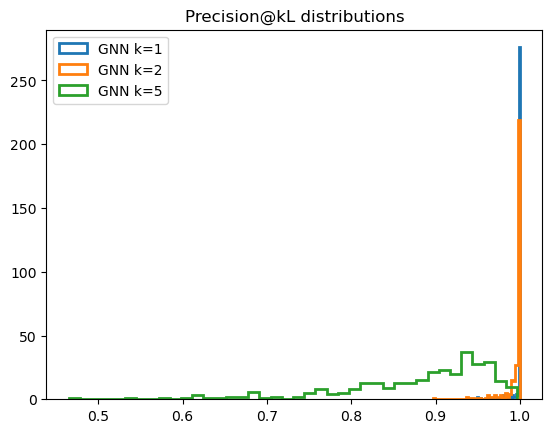

In [22]:
k_values = [1,2,5]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, histtype='step',linewidth=2, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

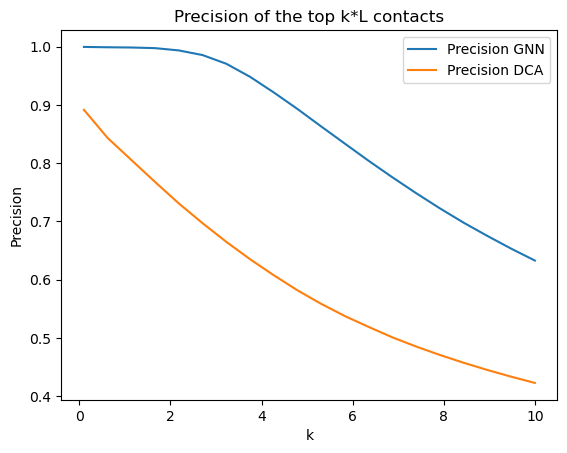

In [23]:
#precision in function of the number of contact to predict
total_k=np.linspace(0.1,10,20)
p_GNN=[]
p_DCA=[]
for k in total_k:

    prec=[]
    prec_dca=[]
    for batch in test_loader:
        batch = batch.to(device)

        #accuracy for a single batch
        with torch.no_grad():
            _, _,pred_logits = model(batch)
            scores = torch.sigmoid(pred_logits.squeeze(-1))
            scores_dca = batch.edge_attr[:, 0].squeeze(-1)  # DCA scores

        mask = batch.edge_mask & batch.pair_mask
        scores = scores[mask]
        scores_dca = scores_dca[mask]
        true_dist = batch.y.squeeze(-1)[mask]
        true_contacts = (true_dist < tr).float()
        
        L = batch.L
        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices
        topk_idx_dca = torch.topk(scores_dca, k=min(topk, scores_dca.numel())).indices

        topk_true = true_contacts[topk_idx]
        topk_true_dca = true_contacts[topk_idx_dca]

        num_correct = topk_true.sum()
        precision = (num_correct / len(topk_true)).item()
        prec.append(precision)

        num_correct_dca = topk_true_dca.sum()
        precision_dca = (num_correct_dca / len(topk_true_dca)).item()
        prec_dca.append(precision_dca)

    p_GNN.append(np.mean(prec))
    p_DCA.append(np.mean(prec_dca))

    

plt.figure()

plt.plot(total_k, p_GNN, label=f"Precision GNN")
plt.plot(total_k, p_DCA, label=f"Precision DCA")


plt.xlabel("k")
plt.ylabel("Precision")
plt.title("Precision of the top k*L contacts")
plt.legend()

plt.show()

Let's evaluate the regressor

In [24]:
def loss_per_graph(batch, pred_dist):
    scores = pred_dist.squeeze(-1)
    y_true = batch.y.squeeze(-1)

    mask = batch.edge_mask

    scores = scores[mask]
    y_true = y_true[mask]

    edge_batch = batch.batch[batch.edge_index[0]][mask]

    loss_tot = []

    for g in edge_batch.unique():
        g_mask = edge_batch == g

        g_scores = scores[g_mask]
        g_true = y_true[g_mask]

        if g_scores.numel() == 0:
            continue

        loss = torch.mean(torch.abs(g_scores - g_true))  # MAE per graph
        loss_tot.append(loss.item())

    return loss_tot

0.24813913654249448


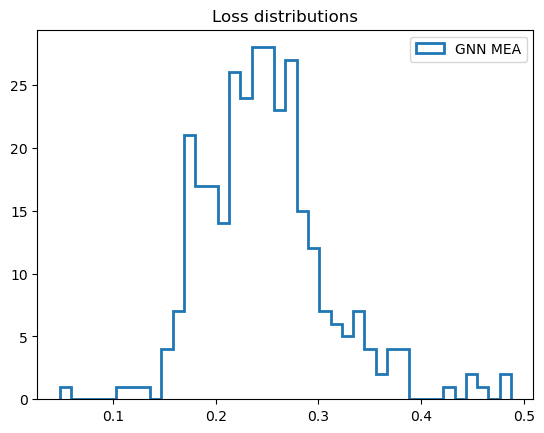

In [25]:
all_losses = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _, pred_dist,_ = model(batch)

        loss_tot= loss_per_graph(batch,pred_dist)
        all_losses.extend(loss_tot)

print(np.mean(all_losses))

plt.hist(all_losses, bins=40, histtype='step',linewidth=2, label=f"GNN MEA")

plt.legend()
plt.title("Loss distributions")
plt.show()


Pearson correlation : 0.7659 (p=0.00e+00)
Spearman correlation: 0.7038 (p=0.00e+00)


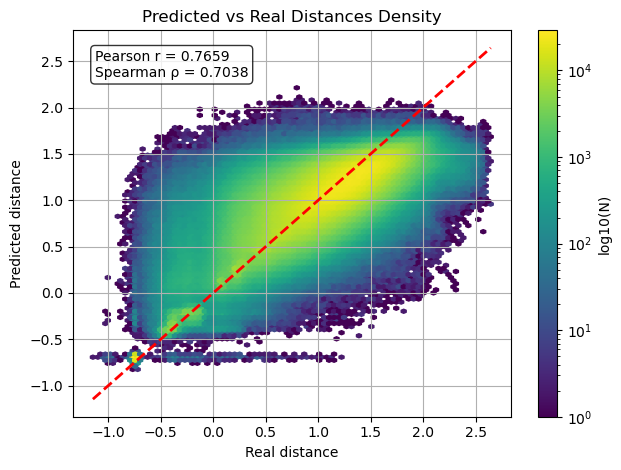

In [26]:
all_pred = []
all_true = []

model.eval()

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        _, pred_dist, _ = model(batch)

        pred = pred_dist.squeeze(-1)
        true = batch.y.squeeze(-1)

        mask = batch.edge_mask

        pred = pred[mask]
        true = true[mask]

        all_pred.append(pred.cpu())
        all_true.append(true.cpu())

# concatenate everything
all_pred = torch.cat(all_pred).numpy()
all_true = torch.cat(all_true).numpy()




# correlations
pearson_corr, pearson_p = pearsonr(all_true, all_pred)
spearman_corr, spearman_p = spearmanr(all_true, all_pred)

print(f"Pearson correlation : {pearson_corr:.4f} (p={pearson_p:.2e})")
print(f"Spearman correlation: {spearman_corr:.4f} (p={spearman_p:.2e})")



# density heatmap
hb = plt.hexbin(
    all_true,
    all_pred,
    gridsize=80,      # increase for finer resolution
    cmap="viridis",
    bins="log"        # log scale helps visualize dense regions
)

# colorbar
cb = plt.colorbar(hb)
cb.set_label("log10(N)")

# ideal diagonal
min_val = min(all_true.min(), all_pred.min())
max_val = max(all_true.max(), all_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    '--',
    color='red',
    linewidth=2
)

plt.text(
    0.05, 0.95,
    f"Pearson r = {pearson_corr:.4f}\n"
    f"Spearman ρ = {spearman_corr:.4f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.xlabel("Real distance")
plt.ylabel("Predicted distance")
plt.title("Predicted vs Real Distances Density")
plt.grid(True)

plt.tight_layout()
plt.show()




Pearson correlation : -0.3020 (p=0.00e+00)
Spearman correlation: -0.1631 (p=0.00e+00)


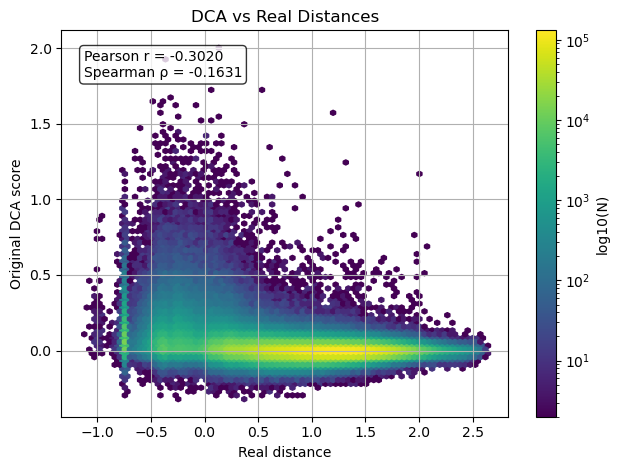

In [27]:
all_original = []
all_true = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        original = batch.edge_attr[:, 0].squeeze(-1)  # DCA scores
        true = batch.y.squeeze(-1)

        mask = batch.edge_mask

        original = original[mask]
        true = true[mask]

        all_original.append(original.cpu())
        all_true.append(true.cpu())

all_original = torch.cat(all_original).numpy()
all_true = torch.cat(all_true).numpy()

# correlations
pearson_corr, pearson_p = pearsonr(all_true, all_original)
spearman_corr, spearman_p = spearmanr(all_true, all_original)

print(f"Pearson correlation : {pearson_corr:.4f} (p={pearson_p:.2e})")
print(f"Spearman correlation: {spearman_corr:.4f} (p={spearman_p:.2e})")



# density heatmap
hb = plt.hexbin(
    all_true,
    all_original,
    gridsize=80,      # increase for finer resolution
    cmap="viridis",
    bins="log"        # log scale helps visualize dense regions
)

plt.text(
    0.05, 0.95,
    f"Pearson r = {pearson_corr:.4f}\n"
    f"Spearman ρ = {spearman_corr:.4f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# colorbar
cb = plt.colorbar(hb)
cb.set_label("log10(N)")

plt.xlabel("Real distance")
plt.ylabel("Original DCA score")
plt.title("DCA vs Real Distances")
plt.grid(True)

plt.tight_layout()
plt.show()

In [28]:
import random
import numpy as np
import matplotlib.pyplot as plt

violations_true = []
violations_pred = []

model.eval()
with torch.no_grad():

    for batch in test_loader:
        batch = batch.to(device)

        _, pred_dist, _ = model(batch)

        pred = pred_dist.squeeze(-1)
        true = batch.y.squeeze(-1)

        edge_index = batch.edge_index[:, batch.edge_mask]

        pred = pred[batch.edge_mask]
        true = true[batch.edge_mask]

        ptr = batch.ptr

        # build ONE fast dictionary per batch
        edge_true = {}
        edge_pred = {}

        for idx in range(edge_index.shape[1]):

            u = int(edge_index[0, idx])
            v = int(edge_index[1, idx])

            edge_true[(u,v)] = float(true[idx])
            edge_pred[(u,v)] = float(pred[idx])

            # symmetry
            edge_true[(v,u)] = float(true[idx])
            edge_pred[(v,u)] = float(pred[idx])

        # process each graph independently
        for g in range(batch.num_graphs):

            start = int(ptr[g])
            end = int(ptr[g+1])

            nodes = list(range(start, end))

            if len(nodes) < 3:
                continue

            # sample only a limited number
            n_samples = 1000

            for _ in range(n_samples):

                i, j, k = random.sample(nodes, 3)

                if (
                    (i,j) in edge_true and
                    (j,k) in edge_true and
                    (i,k) in edge_true
                ):

                    # TRUE
                    dij = np.exp(edge_true[(i,j)])
                    djk = np.exp(edge_true[(j,k)])
                    dik = np.exp(edge_true[(i,k)])

                    violations_true.append(
                        dik - (dij + djk)
                    )

                    # PRED
                    dij = np.exp(edge_pred[(i,j)])
                    djk = np.exp(edge_pred[(j,k)])
                    dik = np.exp(edge_pred[(i,k)])

                    violations_pred.append(
                        dik - (dij + djk)
                    )

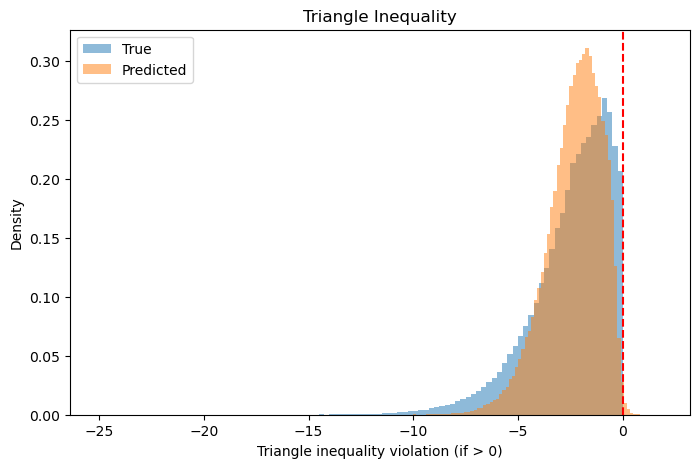

True violation rate: 0.0000%
Pred violation rate: 0.3557%


In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    violations_true,
    bins=100,
    alpha=0.5,
    density=True,
    label="True"
)

plt.hist(
    violations_pred,
    bins=100,
    alpha=0.5,
    density=True,
    label="Predicted"
)

plt.axvline(0, linestyle='--', color='red')

plt.xlabel("Triangle inequality violation (if > 0)")
plt.ylabel("Density")
plt.title("Triangle Inequality")
plt.legend()

plt.show()

eps = 1e-5
viol_true = np.mean(np.array(violations_true) > eps)
viol_pred = np.mean(np.array(violations_pred) > eps)

print(f"True violation rate: {viol_true:.4%}")
print(f"Pred violation rate: {viol_pred:.4%}")

In [30]:
sorted_losses = sorted(enumerate(all_losses), key=lambda x: x[1])

# First 3 minimum values and their indices
# First 3 minimum values and their indices
for idx, val in sorted_losses[:10]:
    print(val, idx)

for idx, val in sorted_losses[len(sorted_losses)-3:len(sorted_losses)]:
    print(val, idx)

0.04835924506187439 289
0.10689953714609146 165
0.12026423960924149 103
0.13015837967395782 39
0.1485704779624939 49
0.15094323456287384 175
0.15164007246494293 278
0.15450631082057953 276
0.15855881571769714 34
0.15921419858932495 216
0.45710596442222595 64
0.48151442408561707 32
0.4875023066997528 18


DataBatch(x=[111, 16], edge_index=[2, 12210], edge_attr=[12210, 2], y=[12210, 1], seq_idx=[111], edge_mask=[12210], pair_mask=[12210], rev_edge_idx=[12210], filename=[1], L=[1], batch=[111], ptr=[2])
['data_PF00072.pkl']


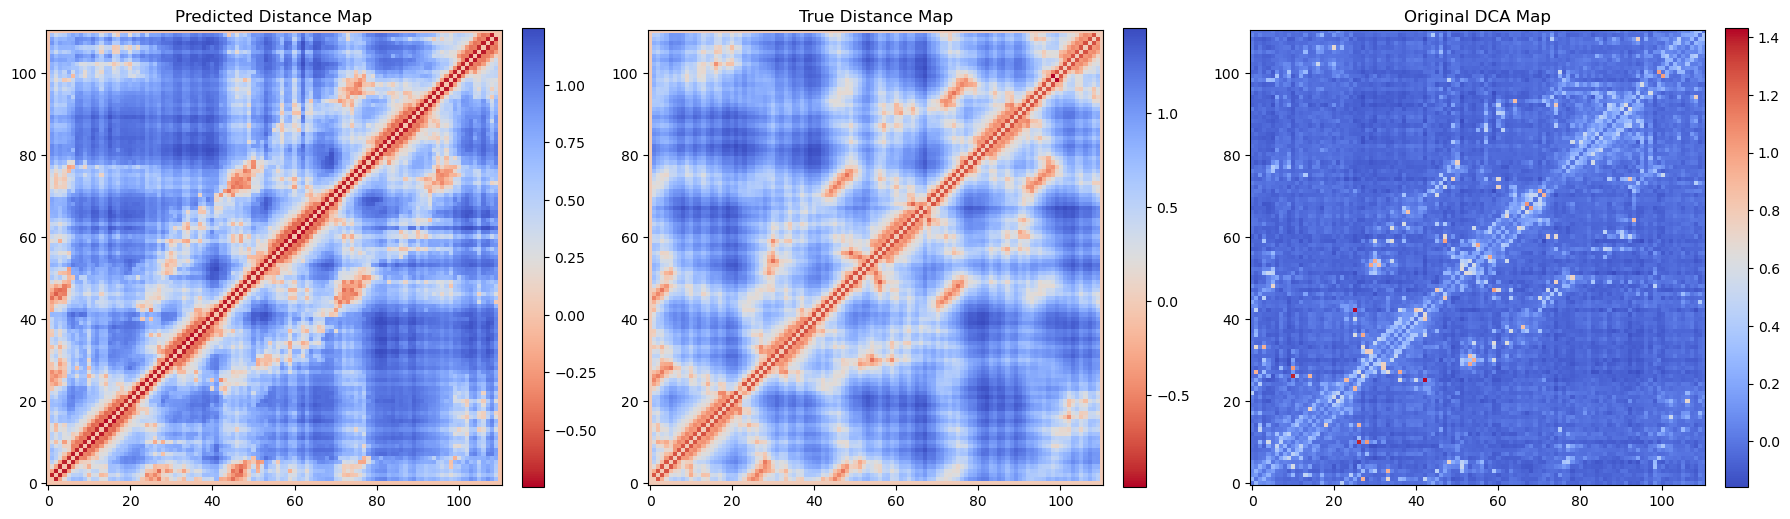

Pearson correlation : 0.9301 (p=0.00e+00)
Spearman correlation: 0.9027 (p=0.00e+00)


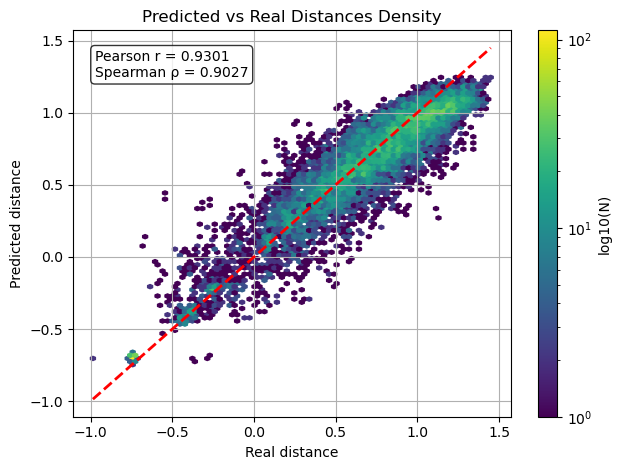

In [31]:
pos=39
i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_dist,_ = model(batch)

            pred = pred_dist.squeeze(-1)
            true = batch.y.squeeze(-1)

            mask = batch.edge_mask

            pred = pred[mask].cpu().numpy()
            true = true[mask].cpu().numpy()


            break
        i+=1

#batch=train_data[pos]
print(batch)
print(batch.filename)

mask = batch.edge_mask #& batch.pair_mask

pred_dist_map = graph_to_matrix(batch, pred_dist.squeeze(-1).cpu(), mask.cpu())
true_dist_map = graph_to_matrix(batch, batch.y.cpu(),mask.cpu())
original_dca_map = graph_to_matrix(batch, batch.edge_attr[:,0].cpu())


fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_dist_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Distance Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---


im1 = axes[1].imshow(true_dist_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Distance Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original DCA Map ---
im2 = axes[2].imshow(original_dca_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Original DCA Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



# correlations
pearson_corr, pearson_p = pearsonr(true, pred)
spearman_corr, spearman_p = spearmanr(true, pred)

print(f"Pearson correlation : {pearson_corr:.4f} (p={pearson_p:.2e})")
print(f"Spearman correlation: {spearman_corr:.4f} (p={spearman_p:.2e})")

# density heatmap
hb = plt.hexbin(
    true,
    pred,
    gridsize=80,      # increase for finer resolution
    cmap="viridis",
    bins="log"        # log scale helps visualize dense regions
)

# colorbar
cb = plt.colorbar(hb)
cb.set_label("log10(N)")

# ideal diagonal
min_val = min(true.min(), pred.min())
max_val = max(true.max(), pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    '--',
    color='red',
    linewidth=2
)

plt.text(
    0.05, 0.95,
    f"Pearson r = {pearson_corr:.4f}\n"
    f"Spearman ρ = {spearman_corr:.4f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.xlabel("Real distance")
plt.ylabel("Predicted distance")
plt.title("Predicted vs Real Distances Density")
plt.grid(True)

plt.tight_layout()
plt.show()



Let's try 3d reconstruct

In [32]:
#non guardare -> option 1

import numpy as np
from Bio.PDB import PDBParser, Polypeptide
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize


# ---------------------------------------------------------------------
# 1) Reproduce the same filtered residue order as mapPDBToHMM
# ---------------------------------------------------------------------
def get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds):
    """
    Rebuilds the residue list in the same spirit/order as mapPDBToHMM.
    Assumes chainIds is a string like 'A' or 'AB'.
    """
    chainIds = list(chainIds)
    structure = PDBParser(QUIET=True).get_structure('void', pdbFile)

    chains = structure[0].get_chains()
    residues = [chain.get_list() for chain in chains if chain.id in chainIds]
    residues = [res for resList in residues for res in resList]

    filtered_residues = []
    filtered_seq = []

    for res in residues:
        if Polypeptide.is_aa(res, standard=True):
            try:
                aa = Polypeptide.protein_letters_3to1[res.get_resname()]
            except Exception:
                continue
            filtered_residues.append(res)
            filtered_seq.append(aa)

    if len(filtered_residues) == 0:
        raise ValueError(f"No standard amino-acid residues found on chains {chainIds}")

    return filtered_residues, ''.join(filtered_seq)


# ---------------------------------------------------------------------
# 2) Representative coordinate per residue
# ---------------------------------------------------------------------
def residue_rep_coord(res, distType='all'):
    """
    distType:
      - 'all'   -> centroid of all atoms in the residue
      - 'alpha' -> CA
      - 'beta'  -> CB, or CA for GLY
    """
    if distType == 'alpha':
        if "CA" in res:
            return res["CA"].get_coord()
        # fallback
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    if distType == 'beta':
        if res.get_resname() == 'GLY':
            if "CA" in res:
                return res["CA"].get_coord()
        else:
            if "CB" in res:
                return res["CB"].get_coord()
        # fallback
        if "CA" in res:
            return res["CA"].get_coord()
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    # distType == 'all'
    atoms = [a.get_coord() for a in res.get_atoms()]
    return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])


def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    """
    Builds an array of shape (len(mi), 3), with NaN for gaps/unmapped positions.
    Your code suggests:
      - mi == -1 => gap
      - positive values are 1-based residue indices in the filtered residue list
    """
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1   # matches your current convention
    idx = mi[valid] - 1
    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq


# ---------------------------------------------------------------------
# 3) Classical MDS initialization
# ---------------------------------------------------------------------
def classical_mds(D, n_components=3):
    """
    Classical MDS for a complete distance matrix.
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    vals = np.maximum(evals[:n_components], 0.0)
    X = evecs[:, :n_components] * np.sqrt(vals)
    return X


def initial_fill_for_mds(D):
    """
    Fill missing distances for a good initial guess.
    """
    D = np.asarray(D, dtype=float)
    out = D.copy()

    finite = np.isfinite(out)
    finite_vals = out[finite & ~np.eye(out.shape[0], dtype=bool)]
    if finite_vals.size == 0:
        raise ValueError("No finite distances available for reconstruction.")

    fill_value = np.median(finite_vals) * 1.5
    out[~np.isfinite(out)] = fill_value
    out = 0.5 * (out + out.T)
    np.fill_diagonal(out, 0.0)
    return out


# ---------------------------------------------------------------------
# 4) Reconstruction by stress minimization over observed pairs
# ---------------------------------------------------------------------
def reconstruct_3d_from_partial_distance_matrix(D, random_state=0, maxiter=800):
    """
    Reconstruct coordinates from a distance matrix that may contain inf entries.
    We minimize stress only over finite pairs.

    Returns:
        X: (N,3) coordinates
        stress: final MSE over observed pairs
        success: optimizer success flag
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D0 = initial_fill_for_mds(D)
    X0 = classical_mds(D0, n_components=3)

    iu = np.triu_indices(n, k=1)
    obs = np.isfinite(D[iu])
    i_idx = iu[0][obs]
    j_idx = iu[1][obs]
    target = D[i_idx, j_idx]

    def objective(x_flat):
        X = x_flat.reshape(n, 3)
        d = np.linalg.norm(X[i_idx] - X[j_idx], axis=1)
        return np.mean((d - target) ** 2)

    res = minimize(
        objective,
        X0.ravel(),
        method='L-BFGS-B',
        options={'maxiter': maxiter, 'ftol': 1e-10}
    )

    X = res.x.reshape(n, 3)
    return X, float(res.fun), bool(res.success)


# ---------------------------------------------------------------------
# 5) Alignment and comparison to PDB coordinates
# ---------------------------------------------------------------------

def kabsch_align(P, Q):
    """
    Align P onto Q with optimal rotation after centering.
    Returns aligned P, centered Q, RMSD.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt

    P_aligned = Pc @ R
    rmsd_val = np.sqrt(np.mean(np.sum((P_aligned - Qc) ** 2, axis=1)))
    return P_aligned, Qc, rmsd_val

def best_alignment_with_mirror(P, Q):
    """
    Distance maps cannot distinguish mirror images.
    Try both orientations and keep the better one.
    """
    P1, Qc1, r1 = kabsch_align(P, Q)

    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2 = kabsch_align(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, "mirrored"
    return P1, Qc1, r1, "normal"

#if i want scaling
def optimal_scaling(P, Q):
    """
    Find scalar s minimizing ||sP - Q||^2
    """
    num = np.sum(P * Q)
    den = np.sum(P * P)
    return num / den

def align_with_scaling(P, Q):
    """
    Align P onto Q with rotation + scaling
    """
    # center
    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    # rotation (Kabsch)
    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1, 1, d]) @ Wt

    P_rot = Pc @ R

    # scaling
    s = optimal_scaling(P_rot, Qc)
    P_scaled = s * P_rot

    rmsd = np.sqrt(np.mean(np.sum((P_scaled - Qc)**2, axis=1)))

    return P_scaled, Qc, rmsd, s


def best_alignment_with_scaling_and_mirror(P, Q):
    # normal
    P1, Qc1, r1, s1 = align_with_scaling(P, Q)

    # mirrored
    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2, s2 = align_with_scaling(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, s2, "mirrored"
    else:
        return P1, Qc1, r1, s1, "normal"



def distance_metrics(D_true, D_pred):
    """
    Compare two complete distance matrices on the upper triangle.
    """
    iu = np.triu_indices_from(D_true, k=1)
    a = D_true[iu]
    b = D_pred[iu]

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 else np.nan
    mae = np.mean(np.abs(a - b)) if len(a) else np.nan
    rmse = np.sqrt(np.mean((a - b) ** 2)) if len(a) else np.nan

    return {"pearson": pearson, "mae": mae, "rmse": rmse}


# ---------------------------------------------------------------------
# 6) End-to-end pipeline
# ---------------------------------------------------------------------
def reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdbFile, chainIds, distType='all'):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # Use only residues that are mapped and have enough finite constraints
    valid = (mi >= 1) & (np.isfinite(dm).sum(axis=1) > 1)

    if valid.sum() < 4:
        raise ValueError("Too few mapped residues with finite distances to reconstruct 3D.")

    D_obs = dm[np.ix_(valid, valid)]

    # Reconstruct 3D from the observed map
    X_rec, stress, success = reconstruct_3d_from_partial_distance_matrix(D_obs)

    # Build PDB reference coordinates in the same order
    # For distType='all', centroid is the most reasonable comparison point.
    ref_coords_full, residues, seq = extract_reference_coords_from_mi(
        pdbFile, chainIds, mi, distType=distType
    )
    X_ref = ref_coords_full[valid]

    # Align reconstruction to the PDB reference
    X_aligned, X_ref_centered, coord_rmsd, scale, orientation = best_alignment_with_scaling_and_mirror(X_rec, X_ref)

    print("Scale factor:", scale)

    # Distance consistency of reconstructed 3D against observed dm
    D_rec = squareform(pdist(X_rec))
    dm_stats = distance_metrics(D_obs, D_rec)

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "optimizer_success": success,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }

#plot

def plot_3d_overlay(X_ref, X_rec_aligned, title="3D comparison"):
    """
    X_ref: reference coordinates (from PDB, centered)
    X_rec_aligned: reconstructed coordinates aligned to reference
    """

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot PDB reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB",
        linewidth=2
    )

    # Plot reconstructed
    ax.plot(
        X_rec_aligned[:, 0], X_rec_aligned[:, 1], X_rec_aligned[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optionally connect corresponding residues (helps visually)
    for i in range(len(X_ref)):
        ax.plot(
            [X_ref[i, 0], X_rec_aligned[i, 0]],
            [X_ref[i, 1], X_rec_aligned[i, 1]],
            [X_ref[i, 2], X_rec_aligned[i, 2]],
            alpha=0.2
        )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()


def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )

                # Write CONECT records (chain connectivity)
        for i in range(1, len(coords)):
            f.write(f"CONECT{i:5d}{i+1:5d}\n")
            f.write(f"CONECT{i+1:5d}{i:5d}\n")
            
        f.write("END\n")

In [33]:
#option 2 (MDS + stess minimization)

import numpy as np
from Bio.PDB import PDBParser, Polypeptide
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize


# ---------------------------------------------------------------------
# 1) Reproduce the same filtered residue order as mapPDBToHMM
# ---------------------------------------------------------------------
def get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds):
    """
    Rebuilds the residue list in the same spirit/order as mapPDBToHMM.
    Assumes chainIds is a string like 'A' or 'AB'.
    """
    chainIds = list(chainIds)
    structure = PDBParser(QUIET=True).get_structure('void', pdbFile)

    chains = structure[0].get_chains()
    residues = [chain.get_list() for chain in chains if chain.id in chainIds]
    residues = [res for resList in residues for res in resList]

    filtered_residues = []
    filtered_seq = []

    for res in residues:
        if Polypeptide.is_aa(res, standard=True):
            try:
                aa = Polypeptide.protein_letters_3to1[res.get_resname()]
            except Exception:
                continue
            filtered_residues.append(res)
            filtered_seq.append(aa)

    if len(filtered_residues) == 0:
        raise ValueError(f"No standard amino-acid residues found on chains {chainIds}")

    return filtered_residues, ''.join(filtered_seq)


# ---------------------------------------------------------------------
# 2) Representative coordinate per residue
# ---------------------------------------------------------------------
def residue_rep_coord(res, distType='all'):
    """
    distType:
      - 'all'   -> centroid of all atoms in the residue
      - 'alpha' -> CA
      - 'beta'  -> CB, or CA for GLY
    """
    if distType == 'alpha':
        if "CA" in res:
            return res["CA"].get_coord()
        # fallback
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    if distType == 'beta':
        if res.get_resname() == 'GLY':
            if "CA" in res:
                return res["CA"].get_coord()
        else:
            if "CB" in res:
                return res["CB"].get_coord()
        # fallback
        if "CA" in res:
            return res["CA"].get_coord()
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    # distType == 'all'
    atoms = [a.get_coord() for a in res.get_atoms()]
    return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])


def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    """
    Builds an array of shape (len(mi), 3), with NaN for gaps/unmapped positions.
    Your code suggests:
      - mi == -1 => gap
      - positive values are 1-based residue indices in the filtered residue list
    """
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1   # matches your current convention
    idx = mi[valid] - 1
    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq


#preprocess distance matrix 

def get_valid_mask(dm, mi, min_finite_per_row=1):
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # residue exists in the mapped structure
    mapped = mi >= 1

    # residue has enough finite distances to be useful
    enough_contacts = np.isfinite(dm).sum(axis=1) >= min_finite_per_row

    return mapped & enough_contacts



# def preprocess_distance_matrix(D, q=0.98):
#     """
#     Symmetrize, remove infinities, and clip extreme values.
#     """
#     D = np.asarray(D, dtype=float)
#     D = 0.5 * (D + D.T)
#     np.fill_diagonal(D, 0.0)

#     finite = np.isfinite(D) & (D > 0)
#     vals = D[finite]

#     if vals.size == 0:
#         raise ValueError("No finite distances in matrix.")

#     fill_value = np.median(vals)
#     upper = np.quantile(vals, q)

#     D2 = D.copy()
#     D2[~np.isfinite(D2)] = fill_value  #########invece che il gap mette un valore medio, non sono sicuro vada molto bene
#     D2 = np.clip(D2, 0.0, upper)

#     return D2



# ---------------------------------------------------------------------
# 3) Classical MDS initialization
# ---------------------------------------------------------------------
def classical_mds(D, n_components=3):
    """
    Classical MDS for a complete distance matrix.
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    vals = np.maximum(evals[:n_components], 0.0)
    X = evecs[:, :n_components] * np.sqrt(vals)
    return X



# ---------------------------------------------------------------------
# 4) Reconstruction by stress minimization over observed pairs
# ---------------------------------------------------------------------
def huber_loss(r, delta=1.0):
    """
    Robust loss for residuals.
    """
    a = np.abs(r)
    return np.where(a <= delta, 0.5 * r * r, delta * (a - 0.5 * delta))


def robust_reconstruct_3d(
    D,
    ignore_band=2,
    chain_lambda=0.1,
    smooth_lambda=0.02,
    n_restarts=10,
    maxiter=1000,
    random_state=0,
):
    """
    Reconstruct 3D coordinates from a noisy distance matrix.

    ignore_band:
        ignore pairs with |i-j| <= ignore_band in the distance fit
        and let the smoothness prior handle local geometry.

    chain_lambda:
        soft penalty on consecutive residues staying too far apart.

    smooth_lambda:
        soft penalty on curvature of the chain.

    Returns:
        best_X, best_stress
    """
    rng = np.random.default_rng(random_state)
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    if np.isinf(D).any() or np.isnan(D).any():
        raise ValueError("D must be gap-free and finite before reconstruction.")

    # enforce symmetry
    D = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)

    # initial guess
    X0 = classical_mds(D, n_components=3)

    iu = np.triu_indices(n, k=1)
    ii = iu[0]
    jj = iu[1]
    targets = D[ii, jj]

    # use only nonlocal pairs in the fit if requested
    keep = np.abs(ii - jj) > ignore_band
    ii = ii[keep]
    jj = jj[keep]
    targets = targets[keep]

    if len(targets) < 3:
        raise ValueError("Too few distance constraints for reconstruction.")

    #chain_target = np.median(np.diag(D, k=1)) if n > 1 else 0.0
    chain_target = 3.80

    def objective(x_flat):
        X = x_flat.reshape(n, 3)

        # fit observed nonlocal distances
        d_obs = np.linalg.norm(X[ii] - X[jj], axis=1)
        resid = d_obs - targets
        stress_data = np.mean(huber_loss(resid, delta=1.0))

        # weak chain continuity prior
        if n > 1:
            d_chain = np.linalg.norm(X[1:] - X[:-1], axis=1)
            stress_chain = np.mean(huber_loss(d_chain - chain_target, delta=1.0))
        else:
            stress_chain = 0.0

        # smoothness prior: avoid jagged backbone
        if n > 2:
            second_diff = X[2:] - 2 * X[1:-1] + X[:-2]
            stress_smooth = np.mean(np.sum(second_diff ** 2, axis=1))
        else:
            stress_smooth = 0.0

        return stress_data + chain_lambda * stress_chain + smooth_lambda * stress_smooth

    best_X = None
    best_fun = np.inf
    best_success = False
    
    for _ in range(n_restarts):
        x_init = X0 + 0.05 * rng.standard_normal(X0.shape)
        res = minimize(
            objective,
            x_init.ravel(),
            method="L-BFGS-B",
            options={"maxiter": maxiter, "ftol": 1e-10},
        )

        if res.fun < best_fun:
            best_fun = res.fun
            best_X = res.x.reshape(n, 3)
            best_success = res.success

    return best_X, best_fun, best_success


# ---------------------------------------------------------------------
# 5) Alignment and comparison to PDB coordinates
# ---------------------------------------------------------------------
#taking the pdb as the target, no gap
def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1
    idx = mi[valid] - 1

    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq



def kabsch_align(P, Q):
    """
    Align P onto Q with optimal rotation after centering.
    Returns aligned P, centered Q, RMSD.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt

    P_aligned = Pc @ R
    rmsd_val = np.sqrt(np.mean(np.sum((P_aligned - Qc) ** 2, axis=1)))
    return P_aligned, Qc, rmsd_val

def best_alignment_with_mirror(P, Q):
    """
    Distance maps cannot distinguish mirror images.
    Try both orientations and keep the better one.
    """
    P1, Qc1, r1 = kabsch_align(P, Q)

    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2 = kabsch_align(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, "mirrored"
    return P1, Qc1, r1, "normal"




#if i want scaling
def optimal_scaling(P, Q):
    """
    Find scalar s minimizing ||sP - Q||^2
    """
    num = np.sum(P * Q)
    den = np.sum(P * P)
    return num / den

def align_with_scaling(P, Q):
    """
    Align P onto Q with rotation + scaling
    """
    # center
    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    # rotation (Kabsch)
    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1, 1, d]) @ Wt

    P_rot = Pc @ R

    # scaling
    s = optimal_scaling(P_rot, Qc)
    P_scaled = s * P_rot

    rmsd = np.sqrt(np.mean(np.sum((P_scaled - Qc)**2, axis=1)))

    return P_scaled, Qc, rmsd, s


def best_alignment_with_scaling_and_mirror(P, Q):
    # normal
    P1, Qc1, r1, s1 = align_with_scaling(P, Q)

    # mirrored
    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2, s2 = align_with_scaling(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, s2, "mirrored"
    else:
        return P1, Qc1, r1, s1, "normal"



def distance_metrics(D_true, D_pred):
    """
    Compare two complete distance matrices on the upper triangle.
    """
    iu = np.triu_indices_from(D_true, k=1)
    a = D_true[iu]
    b = D_pred[iu]

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 else np.nan
    mae = np.mean(np.abs(a - b)) if len(a) else np.nan
    rmse = np.sqrt(np.mean((a - b) ** 2)) if len(a) else np.nan

    return {"pearson": pearson, "mae": mae, "rmse": rmse}


# ---------------------------------------------------------------------
# 6) End-to-end pipeline
# ---------------------------------------------------------------------
def reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdbFile, chainIds, distType='all'):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # residues that actually exist in the mapped structure
    valid = get_valid_mask(dm, mi, min_finite_per_row=1)

    if valid.sum() < 4:
        raise ValueError("Too few mapped residues with finite distances to reconstruct 3D.")

    D_obs = dm[np.ix_(valid, valid)]

    if np.isinf(D_obs).any() or np.isnan(D_obs).any():
        raise ValueError("Gap handling failed: D_obs must be fully finite after filtering.")


    # Reconstruct 3D from the observed map
    X_rec, stress, success = robust_reconstruct_3d(
    D_obs,
    ignore_band=2,
    chain_lambda=0.1, 
    smooth_lambda=0.02,
    n_restarts=20,
    maxiter=1500,
)
    # Build PDB reference coordinates in the same order
    # For distType='all', centroid is the most reasonable comparison point.
    ref_coords_full, residues, seq = extract_reference_coords_from_mi(
        pdbFile, chainIds, mi, distType=distType
    )
    X_ref = ref_coords_full[valid]

    # Align reconstruction to the PDB reference
    X_aligned, X_ref_centered, coord_rmsd, scale, orientation = best_alignment_with_scaling_and_mirror(X_rec, X_ref)
    
    print("Scale factor:", scale)

    # Distance consistency of reconstructed 3D against observed dm
    D_rec = squareform(pdist(X_rec))  ###here is the distance matrix of the reconstructed pdb
    dm_stats = distance_metrics(D_obs, D_rec)

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }


#plot

def plot_3d_overlay(X_ref, X_rec_aligned, title="3D comparison"):
    """
    X_ref: reference coordinates (from PDB, centered)
    X_rec_aligned: reconstructed coordinates aligned to reference
    """

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot PDB reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB",
        linewidth=2
    )

    # Plot reconstructed
    ax.plot(
        X_rec_aligned[:, 0], X_rec_aligned[:, 1], X_rec_aligned[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optionally connect corresponding residues (helps visually)
    for i in range(len(X_ref)):
        ax.plot(
            [X_ref[i, 0], X_rec_aligned[i, 0]],
            [X_ref[i, 1], X_rec_aligned[i, 1]],
            [X_ref[i, 2], X_rec_aligned[i, 2]],
            alpha=0.2
        )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_3d_overlay_masked(X_ref_full, X_rec_full, valid_mask,
                           title="3D comparison", show_connections=True):
    """
    Plot only residues that exist in the reconstructed subset.

    Parameters:
    - X_ref_full: (N,3) reference coordinates (with gaps as NaN or unused)
    - X_rec_full: (M,3) reconstructed coordinates (already filtered OR same size)
    - valid_mask: (N,) boolean mask of valid residues
    """

    valid_mask = np.asarray(valid_mask, dtype=bool)

    # Extract only valid residues from reference
    X_ref = X_ref_full[valid_mask]

    # Handle two cases:
    # 1) X_rec already filtered (same size as X_ref)
    # 2) X_rec is full-size → filter it
    if X_rec_full.shape[0] == valid_mask.shape[0]:
        X_rec = X_rec_full[valid_mask]
    else:
        X_rec = X_rec_full

    if X_ref.shape != X_rec.shape:
        raise ValueError(f"Shape mismatch: ref {X_ref.shape}, rec {X_rec.shape}")

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB (valid residues)",
        linewidth=2
    )

    # Plot reconstruction
    ax.plot(
        X_rec[:, 0], X_rec[:, 1], X_rec[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optional: connect corresponding residues
    if show_connections:
        for i in range(len(X_ref)):
            ax.plot(
                [X_ref[i, 0], X_rec[i, 0]],
                [X_ref[i, 1], X_rec[i, 1]],
                [X_ref[i, 2], X_rec[i, 2]],
                alpha=0.2
            )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()


def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )

                # Write CONECT records (chain connectivity)
        for i in range(1, len(coords)):
            f.write(f"CONECT{i:5d}{i+1:5d}\n")
            f.write(f"CONECT{i+1:5d}{i:5d}\n")
            
        f.write("END\n")

In [34]:
#non guardare ->option3


import numpy as np
from Bio.PDB import PDBParser, Polypeptide
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize


# ---------------------------------------------------------------------
# 1) Reproduce the same filtered residue order as mapPDBToHMM
# ---------------------------------------------------------------------
def get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds):
    """
    Rebuilds the residue list in the same spirit/order as mapPDBToHMM.
    Assumes chainIds is a string like 'A' or 'AB'.
    """
    chainIds = list(chainIds)
    structure = PDBParser(QUIET=True).get_structure('void', pdbFile)

    chains = structure[0].get_chains()
    residues = [chain.get_list() for chain in chains if chain.id in chainIds]
    residues = [res for resList in residues for res in resList]

    filtered_residues = []
    filtered_seq = []

    for res in residues:
        if Polypeptide.is_aa(res, standard=True):
            try:
                aa = Polypeptide.protein_letters_3to1[res.get_resname()]
            except Exception:
                continue
            filtered_residues.append(res)
            filtered_seq.append(aa)

    if len(filtered_residues) == 0:
        raise ValueError(f"No standard amino-acid residues found on chains {chainIds}")

    return filtered_residues, ''.join(filtered_seq)


# ---------------------------------------------------------------------
# 2) Representative coordinate per residue
# ---------------------------------------------------------------------
def residue_rep_coord(res, distType='all'):
    """
    distType:
      - 'all'   -> centroid of all atoms in the residue
      - 'alpha' -> CA
      - 'beta'  -> CB, or CA for GLY
    """
    if distType == 'alpha':
        if "CA" in res:
            return res["CA"].get_coord()
        # fallback
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    if distType == 'beta':
        if res.get_resname() == 'GLY':
            if "CA" in res:
                return res["CA"].get_coord()
        else:
            if "CB" in res:
                return res["CB"].get_coord()
        # fallback
        if "CA" in res:
            return res["CA"].get_coord()
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    # distType == 'all'
    atoms = [a.get_coord() for a in res.get_atoms()]
    return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])


def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    """
    Builds an array of shape (len(mi), 3), with NaN for gaps/unmapped positions.
    Your code suggests:
      - mi == -1 => gap
      - positive values are 1-based residue indices in the filtered residue list
    """
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1   # matches your current convention
    idx = mi[valid] - 1
    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq


#preprocess distance matrix 

def get_valid_mask(dm, mi, min_finite_per_row=1):
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # residue exists in the mapped structure
    mapped = mi >= 1

    # residue has enough finite distances to be useful
    enough_contacts = np.isfinite(dm).sum(axis=1) >= min_finite_per_row

    return mapped & enough_contacts



# def preprocess_distance_matrix(D, q=0.98):
#     """
#     Symmetrize, remove infinities, and clip extreme values.
#     """
#     D = np.asarray(D, dtype=float)
#     D = 0.5 * (D + D.T)
#     np.fill_diagonal(D, 0.0)

#     finite = np.isfinite(D) & (D > 0)
#     vals = D[finite]

#     if vals.size == 0:
#         raise ValueError("No finite distances in matrix.")

#     fill_value = np.median(vals)
#     upper = np.quantile(vals, q)

#     D2 = D.copy()
#     D2[~np.isfinite(D2)] = fill_value  #########invece che il gap mette un valore medio, non sono sicuro vada molto bene
#     D2 = np.clip(D2, 0.0, upper)

#     return D2



# ---------------------------------------------------------------------
# 3) Classical MDS initialization
# ---------------------------------------------------------------------
def classical_mds(D, n_components=3):
    """
    Classical MDS for a complete distance matrix.
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    vals = np.maximum(evals[:n_components], 0.0)
    X = evecs[:, :n_components] * np.sqrt(vals)
    return X



# ---------------------------------------------------------------------
# 4) Reconstruction by stress minimization over observed pairs
# ---------------------------------------------------------------------


def robust_reconstruct_3d_exact_bonds(
    D,
    valid_mask,
    bond_len=3.8,
    ignore_band=2,
    smooth_lambda=0.02,
    n_restarts=10,
    maxiter=1000,
    random_state=0,
):
    """
    Reconstruct 3D coordinates from a distance matrix while enforcing
    exact backbone bond length between consecutive REAL residues.

    Parameters
    ----------
    D : (N, N) array
        Full distance matrix. Gaps may be NaN/inf anywhere.
    valid_mask : (N,) boolean array
        True for real residues, False for gaps.
    bond_len : float
        Exact distance between consecutive residues in the compact chain.
    ignore_band : int
        Ignore pairs with |i-j| <= ignore_band in the distance fit.
        This is applied after removing gaps.
    smooth_lambda : float
        Weight of curvature regularization.
    n_restarts : int
        Number of random restarts.
    maxiter : int
        Max optimizer iterations.
    random_state : int
        RNG seed.

    Returns
    -------
    X_full : (N, 3) array
        Reconstructed coordinates with NaN at gaps.
    X_compact : (M, 3) array
        Coordinates for only the real residues.
    best_fun : float
        Final objective value.
    best_success : bool
        Optimizer success flag.
    valid_idx : (M,) array
        Indices of real residues in the original full array.
    """
    rng = np.random.default_rng(random_state)

    D = np.asarray(D, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)

    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise ValueError("D must be a square matrix.")
    if len(valid_mask) != D.shape[0]:
        raise ValueError("valid_mask must have the same length as D.shape[0].")

    # Keep only real residues
    valid_idx = np.flatnonzero(valid_mask)
    m = len(valid_idx)

    if m < 2:
        raise ValueError("Need at least 2 real residues to reconstruct a chain.")

    # Compact observed matrix
    D_obs = D[np.ix_(valid_idx, valid_idx)].copy()
    D_obs = 0.5 * (D_obs + D_obs.T)
    np.fill_diagonal(D_obs, 0.0)

    # Use only finite nonlocal pairs in the fit
    iu = np.triu_indices(m, k=1)
    ii, jj = iu
    targets = D_obs[ii, jj]

    keep = np.isfinite(targets) & (np.abs(ii - jj) > ignore_band)
    ii = ii[keep]
    jj = jj[keep]
    targets = targets[keep]

    if len(targets) < 3:
        raise ValueError("Too few usable distance constraints after filtering.")

    def huber_loss(r, delta=1.0):
        a = np.abs(r)
        return np.where(a <= delta, 0.5 * r * r, delta * (a - 0.5 * delta))

    def classical_mds(Dmat, n_components=3):
        Dmat = np.asarray(Dmat, dtype=float)
        n = Dmat.shape[0]
        D2 = Dmat ** 2
        J = np.eye(n) - np.ones((n, n)) / n
        B = -0.5 * J @ D2 @ J
        evals, evecs = np.linalg.eigh(B)
        idx = np.argsort(evals)[::-1]
        evals = evals[idx]
        evecs = evecs[:, idx]
        vals = np.maximum(evals[:n_components], 0.0)
        return evecs[:, :n_components] * np.sqrt(vals)

    def build_coords(params):
        """
        Params:
          - first 3 values: x0
          - remaining values: raw direction vectors for each bond
        Bond length is enforced exactly by normalization.
        """
        x0 = params[:3]

        if m == 1:
            return x0[None, :]

        U = params[3:].reshape(m - 1, 3)
        norms = np.linalg.norm(U, axis=1, keepdims=True)
        dirs = U / np.maximum(norms, 1e-12)   # unit directions
        steps = bond_len * dirs

        X = np.empty((m, 3), dtype=float)
        X[0] = x0
        X[1:] = x0 + np.cumsum(steps, axis=0)
        return X

    def objective(params):
        X = build_coords(params)

        # Fit observed distances
        d_obs = np.linalg.norm(X[ii] - X[jj], axis=1)
        resid = d_obs - targets
        stress_data = np.mean(huber_loss(resid, delta=1.0))

        # Optional smoothness prior
        if m > 2:
            second_diff = X[2:] - 2 * X[1:-1] + X[:-2]
            stress_smooth = np.mean(np.sum(second_diff ** 2, axis=1))
        else:
            stress_smooth = 0.0

        return stress_data + smooth_lambda * stress_smooth

    # Initial guess from MDS
    X0 = classical_mds(D_obs, n_components=3)
    if not np.all(np.isfinite(X0)) or np.allclose(X0, 0):
        X0 = rng.normal(size=(m, 3))

    if m == 1:
        base_params = X0[0].copy()
    else:
        diffs = np.diff(X0, axis=0)
        norms = np.linalg.norm(diffs, axis=1, keepdims=True)
        dirs0 = diffs / np.maximum(norms, 1e-12)
        U0 = dirs0 + 0.05 * rng.standard_normal(dirs0.shape)
        base_params = np.concatenate([X0[0], U0.ravel()])

    best_fun = np.inf
    best_X = None
    best_success = False

    for _ in range(n_restarts):
        p0 = base_params.copy()
        if m >= 1:
            p0[:3] += 0.2 * rng.standard_normal(3)
        if m > 1:
            p0[3:] += 0.2 * rng.standard_normal(p0[3:].shape)

        res = minimize(
            objective,
            p0,
            method="L-BFGS-B",
            options={"maxiter": maxiter, "ftol": 1e-10},
        )

        if res.fun < best_fun:
            best_fun = res.fun
            best_X = build_coords(res.x)
            best_success = res.success

    # Expand back to full length, with NaN at gaps
    X_full = np.full((D.shape[0], 3), np.nan, dtype=float)
    X_full[valid_idx] = best_X

    return X_full, best_X, best_fun, best_success, valid_idx


# ---------------------------------------------------------------------
# 5) Alignment and comparison to PDB coordinates
# ---------------------------------------------------------------------
#taking the pdb as the target, no gap
def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1
    idx = mi[valid] - 1

    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq



def kabsch_align(P, Q):
    """
    Align P onto Q with optimal rotation after centering.
    Returns aligned P, centered Q, RMSD.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt

    P_aligned = Pc @ R
    rmsd_val = np.sqrt(np.mean(np.sum((P_aligned - Qc) ** 2, axis=1)))
    return P_aligned, Qc, rmsd_val

def best_alignment_with_mirror(P, Q):
    """
    Distance maps cannot distinguish mirror images.
    Try both orientations and keep the better one.
    """
    P1, Qc1, r1 = kabsch_align(P, Q)

    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2 = kabsch_align(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, "mirrored"
    return P1, Qc1, r1, "normal"




def distance_metrics(D_true, D_pred):
    """
    Compare two complete distance matrices on the upper triangle.
    """
    iu = np.triu_indices_from(D_true, k=1)
    a = D_true[iu]
    b = D_pred[iu]

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 else np.nan
    mae = np.mean(np.abs(a - b)) if len(a) else np.nan
    rmse = np.sqrt(np.mean((a - b) ** 2)) if len(a) else np.nan

    return {"pearson": pearson, "mae": mae, "rmse": rmse}


# ---------------------------------------------------------------------
# 6) End-to-end pipeline
# ---------------------------------------------------------------------
def reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdbFile, chainIds, distType='alpha'):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # residues that actually exist in the mapped structure
    valid = get_valid_mask(dm, mi, min_finite_per_row=1)

    if valid.sum() < 4:
        raise ValueError("Too few mapped residues with finite distances to reconstruct 3D.")

    D_obs = dm[np.ix_(valid, valid)]

    if np.isinf(D_obs).any() or np.isnan(D_obs).any():
        raise ValueError("Gap handling failed: D_obs must be fully finite after filtering.")


    X_full, X_rec, stress, success, valid_idx = robust_reconstruct_3d_exact_bonds(
        dm,
        valid_mask=valid,
        bond_len=3.8,
        ignore_band=2,
        smooth_lambda=0.02,
        n_restarts=20,
        maxiter=1500,
    )
    # Build PDB reference coordinates in the same order
    # For distType='all', centroid is the most reasonable comparison point.
    ref_coords_full, residues, seq = extract_reference_coords_from_mi(
        pdbFile, chainIds, mi, distType=distType
    )
    X_ref = ref_coords_full[valid]

    # Align reconstruction to the PDB reference
    X_aligned, X_ref_centered, coord_rmsd, orientation = best_alignment_with_mirror(X_rec, X_ref)
    

    # Distance consistency of reconstructed 3D against observed dm
    D_rec = squareform(pdist(X_rec))
    dm_stats = distance_metrics(D_obs, D_rec)

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }


#plot

def plot_3d_overlay_masked(X_ref_full, X_rec_full, valid_mask,
                           title="3D comparison", show_connections=True):
    """
    Plot only residues that exist in the reconstructed subset.

    Parameters:
    - X_ref_full: (N,3) reference coordinates (with gaps as NaN or unused)
    - X_rec_full: (M,3) reconstructed coordinates (already filtered OR same size)
    - valid_mask: (N,) boolean mask of valid residues
    """

    valid_mask = np.asarray(valid_mask, dtype=bool)

    # Extract only valid residues from reference
    X_ref = X_ref_full[valid_mask]

    # Handle two cases:
    # 1) X_rec already filtered (same size as X_ref)
    # 2) X_rec is full-size → filter it
    if X_rec_full.shape[0] == valid_mask.shape[0]:
        X_rec = X_rec_full[valid_mask]
    else:
        X_rec = X_rec_full

    if X_ref.shape != X_rec.shape:
        raise ValueError(f"Shape mismatch: ref {X_ref.shape}, rec {X_rec.shape}")

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB (valid residues)",
        linewidth=2
    )

    # Plot reconstruction
    ax.plot(
        X_rec[:, 0], X_rec[:, 1], X_rec[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optional: connect corresponding residues
    if show_connections:
        for i in range(len(X_ref)):
            ax.plot(
                [X_ref[i, 0], X_rec[i, 0]],
                [X_ref[i, 1], X_rec[i, 1]],
                [X_ref[i, 2], X_rec[i, 2]],
                alpha=0.2
            )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()


def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )

                # Write CONECT records (chain connectivity)
        for i in range(1, len(coords)):
            f.write(f"CONECT{i:5d}{i+1:5d}\n")
            f.write(f"CONECT{i+1:5d}{i:5d}\n")
            
        f.write("END\n")

In [35]:
#non guardare -> option 4


import numpy as np
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform


# ==========================================================
# Low-rank EDM reconstruction
# ==========================================================

def lowrank_edm_reconstruct(
    D,
    rank=3,
    mask=None,
    n_restarts=10,
    maxiter=1500,
    random_state=0,
):
    """
    Low-rank Euclidean Distance Matrix fitting.

    Solves:

        min_X sum_ij w_ij (||x_i-x_j||^2 - D_ij^2)^2

    where:
        X in R^{n x rank}

    Parameters
    ----------
    D : ndarray (n,n)
        Distance matrix.
    rank : int
        Embedding dimension.
    mask : ndarray (n,n) or None
        Binary mask for observed entries.
    n_restarts : int
        Number of random restarts.
    maxiter : int
        L-BFGS iterations.

    Returns
    -------
    X_best : ndarray (n, rank)
    best_loss : float
    """

    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    # Symmetrize
    D = 0.5 * (D + D.T)

    # Squared distances
    D2 = D ** 2

    # Observation mask
    if mask is None:
        W = np.isfinite(D).astype(float)
    else:
        W = mask.astype(float)

    np.fill_diagonal(W, 0.0)

    # Replace NaNs
    D2 = np.nan_to_num(D2, nan=0.0)

    best_loss = np.inf
    X_best = None

    def objective_and_grad(x_flat):
        X = x_flat.reshape(n, rank)

        diff = X[:, None, :] - X[None, :, :]
        dist2 = np.sum(diff**2, axis=2)

        R = W * (dist2 - D2)

        obj = 0.5 * np.sum(R**2)

        grad = np.zeros_like(X)

        for i in range(n):
            grad[i] = 4.0 * np.sum(
                R[i, :, None] * diff[i],
                axis=0
            )

        return obj, grad.ravel()

    rng = np.random.default_rng(random_state)

    for restart in range(n_restarts):

        X0 = 0.01 * rng.normal(size=(n, rank))

        result = minimize(
            fun=lambda x: objective_and_grad(x)[0],
            x0=X0.ravel(),
            jac=lambda x: objective_and_grad(x)[1],
            method="L-BFGS-B",
            options={
                "maxiter": maxiter,
                "ftol": 1e-12,
            },
        )

        if result.fun < best_loss:
            best_loss = result.fun
            X_best = result.x.reshape(n, rank)

    return X_best, best_loss


# ==========================================================
# Your pipeline
# ==========================================================

def reconstruct_and_compare_with_mapPDBToHMM(
    dm,
    mi,
    pdbFile,
    chainIds,
    distType='all'
):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """

    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # ======================================================
    # Keep only valid mapped residues
    # ======================================================

    valid = (
        (mi >= 1)
        & (np.isfinite(dm).sum(axis=1) > 1)
    )

    if valid.sum() < 4:
        raise ValueError(
            "Too few mapped residues with finite distances "
            "to reconstruct 3D."
        )

    D_obs = dm[np.ix_(valid, valid)]

    # ======================================================
    # Preprocess distance matrix
    # ======================================================

    if np.isinf(D_obs).any() or np.isnan(D_obs).any():
        raise ValueError("Gap handling failed: D_obs must be fully finite after filtering.")
    D_clean = D_obs

    # ======================================================
    # Build observation mask
    # ======================================================

    mask = np.isfinite(D_clean).astype(float)

    # Replace NaNs/infs
    D_clean = np.nan_to_num(D_clean, nan=0.0)

    # ======================================================
    # LOW-RANK EDM FITTING
    # ======================================================

    X_rec, stress = lowrank_edm_reconstruct(
        D_clean,
        rank=3,
        mask=mask,
        n_restarts=20,
        maxiter=1500,
    )

    # ======================================================
    # Build PDB reference coordinates
    # ======================================================

    ref_coords_full, residues, seq = \
        extract_reference_coords_from_mi(
            pdbFile,
            chainIds,
            mi,
            distType=distType
        )

    X_ref = ref_coords_full[valid]

    # ======================================================
    # Align reconstruction to reference
    # ======================================================

    X_aligned, X_ref_centered, coord_rmsd, scale, orientation = \
        best_alignment_with_scaling_and_mirror(
            X_rec,
            X_ref
        )

    print("Scale factor:", scale)

    # ======================================================
    # Distance consistency
    # ======================================================

    D_rec = squareform(pdist(X_rec))

    dm_stats = distance_metrics(
        D_obs,
        D_rec
    )

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }

In [36]:
#opzion 5 (edm + stress refinement)



import numpy as np
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform


# ==========================================================
# Low-rank EDM reconstruction
# ==========================================================

def lowrank_edm_reconstruct(
    D,
    rank=3,
    mask=None,
    n_restarts=10,
    maxiter=1500,
    random_state=0,
):
    """
    Low-rank Euclidean Distance Matrix fitting.

    Solves:

        min_X sum_ij w_ij (||x_i-x_j||^2 - D_ij^2)^2

    where:
        X in R^{n x rank}

    Parameters
    ----------
    D : ndarray (n,n)
        Distance matrix.
    rank : int
        Embedding dimension.
    mask : ndarray (n,n) or None
        Binary mask for observed entries.
    n_restarts : int
        Number of random restarts.
    maxiter : int
        L-BFGS iterations.

    Returns
    -------
    X_best : ndarray (n, rank)
    best_loss : float
    """

    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    # Symmetrize
    D = 0.5 * (D + D.T)

    # Squared distances
    D2 = D ** 2

    # Observation mask
    if mask is None:
        W = np.isfinite(D).astype(float)
    else:
        W = mask.astype(float)

    np.fill_diagonal(W, 0.0)

    # Replace NaNs
    D2 = np.nan_to_num(D2, nan=0.0)

    best_loss = np.inf
    X_best = None

    def objective_and_grad(x_flat):
        X = x_flat.reshape(n, rank)

        diff = X[:, None, :] - X[None, :, :]
        dist2 = np.sum(diff**2, axis=2)

        R = W * (dist2 - D2)

        obj = 0.5 * np.sum(R**2)

        grad = np.zeros_like(X)

        for i in range(n):
            grad[i] = 4.0 * np.sum(
                R[i, :, None] * diff[i],
                axis=0
            )

        return obj, grad.ravel()

    rng = np.random.default_rng(random_state)

    for restart in range(n_restarts):

        X0 = 0.01 * rng.normal(size=(n, rank))

        result = minimize(
            fun=lambda x: objective_and_grad(x)[0],
            x0=X0.ravel(),
            jac=lambda x: objective_and_grad(x)[1],
            method="L-BFGS-B",
            options={
                "maxiter": maxiter,
                "ftol": 1e-12,
            },
        )

        if result.fun < best_loss:
            best_loss = result.fun
            X_best = result.x.reshape(n, rank)

    return X_best, best_loss

def stress_refinement(
    X0,
    D,
    mask=None,
    maxiter=1000,
):
    """
    Refine coordinates using classical stress minimization.

    Minimizes:
        sum_ij w_ij (||xi-xj|| - Dij)^2
    """

    D = np.asarray(D, dtype=float)
    n, rank = X0.shape

    if mask is None:
        W = np.isfinite(D).astype(float)
    else:
        W = mask.astype(float)

    np.fill_diagonal(W, 0.0)

    D = np.nan_to_num(D, nan=0.0)

    eps = 1e-12

    def objective_and_grad(x_flat):

        X = x_flat.reshape(n, rank)

        diff = X[:, None, :] - X[None, :, :]

        dist = np.sqrt(
            np.sum(diff**2, axis=2) + eps
        )

        R = W * (dist - D)

        obj = 0.5 * np.sum(R**2)

        grad = np.zeros_like(X)

        for i in range(n):

            tmp = (
                R[i, :, None]
                * diff[i]
                / dist[i, :, None]
            )

            tmp[~np.isfinite(tmp)] = 0.0

            grad[i] = np.sum(tmp, axis=0)

        return obj, grad.ravel()

    result = minimize(
        fun=lambda x: objective_and_grad(x)[0],
        x0=X0.ravel(),
        jac=lambda x: objective_and_grad(x)[1],
        method="L-BFGS-B",
        options={
            "maxiter": maxiter,
            "ftol": 1e-12,
        },
    )

    return result.x.reshape(n, rank), result.fun

# ==========================================================
# Your pipeline
# ==========================================================

def reconstruct_and_compare_with_mapPDBToHMM(
    dm,
    mi,
    pdbFile,
    chainIds,
    distType='all'
):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """

    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # ======================================================
    # Keep only valid mapped residues
    # ======================================================

    valid = (
        (mi >= 1)
        & (np.isfinite(dm).sum(axis=1) > 1)
    )

    if valid.sum() < 4:
        raise ValueError(
            "Too few mapped residues with finite distances "
            "to reconstruct 3D."
        )

    D_obs = dm[np.ix_(valid, valid)]

    # ======================================================
    # Preprocess distance matrix
    # ======================================================

    if np.isinf(D_obs).any() or np.isnan(D_obs).any():
        raise ValueError("Gap handling failed: D_obs must be fully finite after filtering.")
    D_clean = D_obs

    # ======================================================
    # Build observation mask
    # ======================================================

    mask = np.isfinite(D_clean).astype(float)

    # Replace NaNs/infs
    D_clean = np.nan_to_num(D_clean, nan=0.0)

    # ======================================================
    # LOW-RANK EDM FITTING
    # ======================================================

    X_rec, edm_loss = lowrank_edm_reconstruct(
        D_clean,
        rank=3,
        mask=mask,
        n_restarts=20,
        maxiter=1500,
    )

    # ======================================================
    # STRESS REFINEMENT
    # ======================================================

    X_rec, stress = stress_refinement(
        X_rec,
        D_clean,
        mask=mask,
        maxiter=1000,
    )


    # ======================================================
    # Build PDB reference coordinates
    # ======================================================

    ref_coords_full, residues, seq = \
        extract_reference_coords_from_mi(
            pdbFile,
            chainIds,
            mi,
            distType=distType
        )

    X_ref = ref_coords_full[valid]

    # ======================================================
    # Align reconstruction to reference
    # ======================================================

    X_aligned, X_ref_centered, coord_rmsd, scale, orientation = \
        best_alignment_with_scaling_and_mirror(
            X_rec,
            X_ref
        )

    print("Scale factor:", scale)

    # ======================================================
    # Distance consistency
    # ======================================================

    D_rec = squareform(pdist(X_rec))

    dm_stats = distance_metrics(
        D_obs,
        D_rec
    )

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }

Scale factor: 0.9556028754011695
6.1387548339974565e-09 4.081252879632512 {'pearson': np.float64(0.9999999999999873), 'mae': np.float64(7.449095766419346e-07), 'rmse': np.float64(1.0212451711546402e-06)}


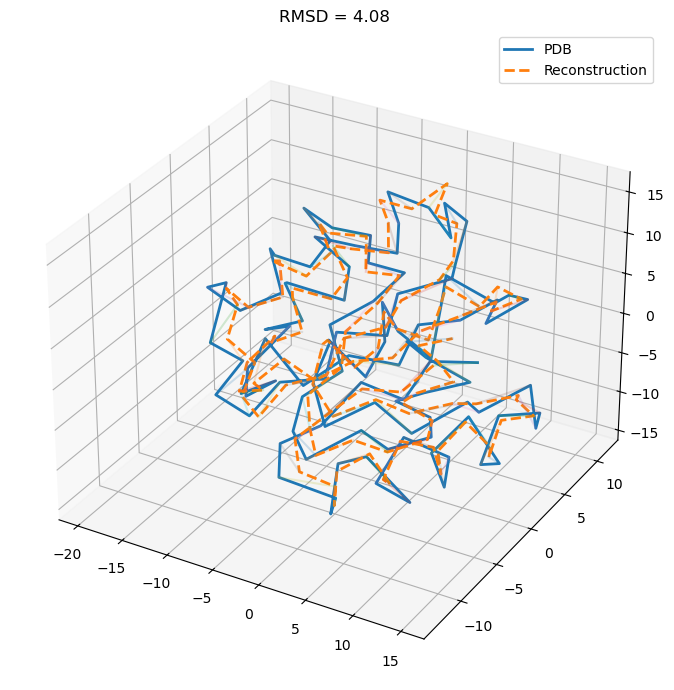

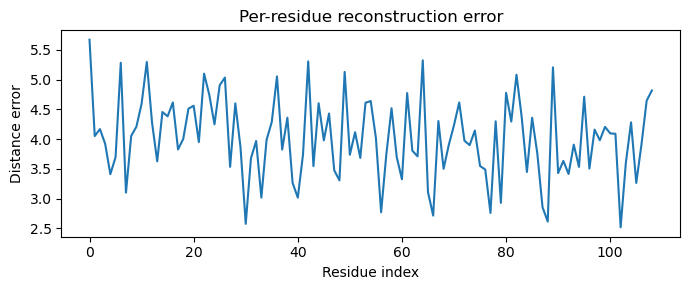

Scale factor: 1.017233597450388
19273.250356980167 4.496923009848643 {'pearson': np.float64(0.9536513281885587), 'mae': np.float64(1.4148860765247153), 'rmse': np.float64(1.815987481118339)}


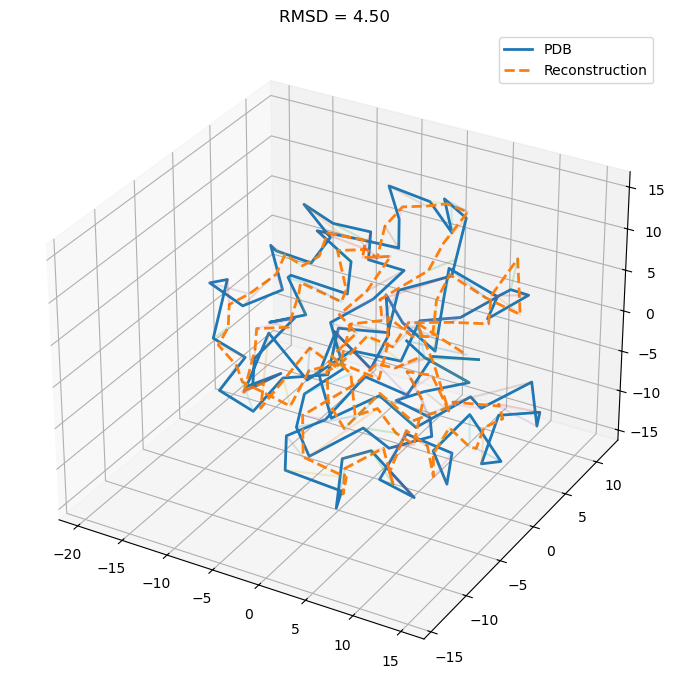

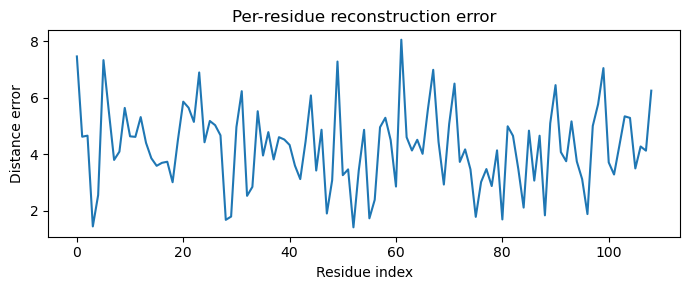

In [37]:
#real distance map


from sequenceHandler import mapPDBToHMM
pfam_id= "PF00072"
pdb_file = f"PDB/{pfam_id}.pdb"
chain_id = "A"
hmm_file = f"HMM/{pfam_id}.hmm"
hmm_file_2 = "None"        
output_map_file = "None"  




_, mi, aligned_sequence = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='all')
true_dm = 8 * np.exp(np.asanyarray(true_dist_map))

result = reconstruct_and_compare_with_mapPDBToHMM(true_dm, mi, pdb_file, chain_id, distType='all')
print(result["stress"], result["coord_rmsd"], result["distance_metrics"])
valid = result["valid_mask"]

plot_3d_overlay(
    result["X_ref_centered"],
    result["X_aligned"], 
    title=f"RMSD = {result['coord_rmsd']:.2f}"
)


plot_error_per_residue(
    result["X_ref_centered"],
    result["X_aligned"]
)

# Save reference
save_coords_as_pdb(result["X_ref_centered"], "reference.pdb")
#save reconstructed
save_coords_as_pdb(result["X_aligned"], "reconstructed.pdb")


#predicted distance map
pred_dm = 8 * np.exp(np.asanyarray(pred_dist_map))
result = reconstruct_and_compare_with_mapPDBToHMM(pred_dm, mi, pdb_file, chain_id, distType='all')
print(result["stress"], result["coord_rmsd"], result["distance_metrics"])
valid = result["valid_mask"]

plot_3d_overlay(
    result["X_ref_centered"],
    result["X_aligned"],
    title=f"RMSD = {result['coord_rmsd']:.2f}"
)


plot_error_per_residue(
    result["X_ref_centered"],
    result["X_aligned"]
)


# Save reconstructed (aligned)
save_coords_as_pdb(result["X_aligned"], "reconstructed_GNN.pdb")
